<a href="https://colab.research.google.com/github/HinaH1/dental-caries-detection-segmentation/blob/main/phase_one/experiment_three_YOLO26_seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment Three: YOLO26-seg Instance Segmentation

## Overview
This notebook documents the third experiment of Phase One.
Following on from Experiment Two, which trained a YOLO26 instance segmentation model on the tumverilerdeneme dataset, this experiment applies two YOLO6-seg to enable a improve the model from the first run.

The dataset had been reviewed and approved by a dental professional as
clinically suitable for this task. Instance segmentation was used to produce
pixel-level masks that trace the exact boundary of each carious lesion rather
than just drawing a rectangle around it.

## Dataset
The tumverilerdeneme dataset was downloaded from Roboflow. The dataset uses
polygon-based segmentation annotations in YOLO format, with annotations
covering regions of dental caries.

## Training Configuration
Two training runs were carried out. The first established a baseline and
the second used a larger model variant, increased image size, and early stopping
to investigate whether additional capacity and resolution could improve performance.

| Parameter        | Baseline Run    | Improved Run         |
|------------------|-----------------|----------------------|
| Model            | YOLO26n-seg    | YOLO26n-seg         |
| Epochs           | 50              | 100 (max)            |
| Image size       | 640             | 768                  |
| Batch size       | 4               | 4                    |
| Early stopping   | No              | Yes, patience 20     |

## Environment Setup and Dataset Download
The following cell installs the required libraries and downloads the
tumverilerdeneme dataset from Roboflow.
Replace the placeholder API key with your own Roboflow credentials before running.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
from google.colab import userdata

api_key = userdata.get("ROBOFLOW")
rf = Roboflow(api_key=api_key)
project = rf.workspace("hinas-workspace").project("tumverilerdeneme-ap2eh")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to tümverilerdeneme-3 in yolov8:: 100%|██████████| 1897/1897 [00:00<00:00, 10324.20it/s]


## Data Configuration
The dataset paths in the data.yaml file are updated to match the Colab directory
structure before training begins.

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'tümverilerdeneme-3', 'sample_data']


In [ ]:
!ls /content/tümverilerdeneme-3

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
import yaml

yaml_path = "/content/tümverilerdeneme-3/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Fix paths
data["train"] = "/content/tümverilerdeneme-3/train/images"
data["val"] = "/content/tümverilerdeneme-3/valid/images"
data["test"] = "tümverilerdeneme-3/test/images"

# Save new YAML
with open("/content/data_fixed.yaml", "w") as f:
    yaml.dump(data, f)

print(data)

{'names': ['caries'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'tumverilerdeneme-ap2eh', 'url': 'https://universe.roboflow.com/hinas-workspace/tumverilerdeneme-ap2eh/dataset/3', 'version': 3, 'workspace': 'hinas-workspace'}, 'test': 'tümverilerdeneme-3/test/images', 'train': '/content/tümverilerdeneme-3/train/images', 'val': '/content/tümverilerdeneme-3/valid/images'}


In [ ]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    img_dir = Path(f"/content/tümverilerdeneme-3/{split}/images")
    label_dir = Path(f"/content/tümverilerdeneme-3/{split}/labels")

    print(split)
    print("images:", len(list(img_dir.glob("*"))))
    print("labels:", len(list(label_dir.glob("*.txt"))))
    print("-"*30)


train
images: 757
labels: 757
------------------------------
valid
images: 95
labels: 95
------------------------------
test
images: 94
labels: 94
------------------------------


## Sample Annotation Visualisation
The following cell displays a sample of training images with their segmentation
annotations overlaid, for visual inspection of the annotation quality before
training begins.

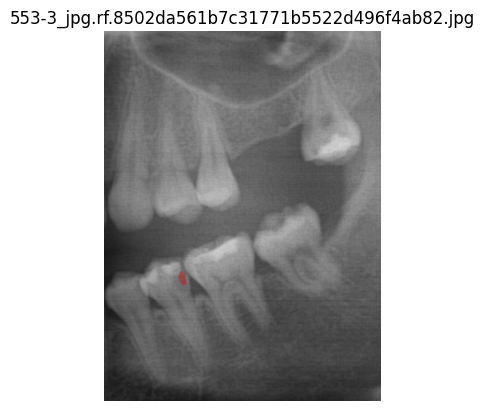

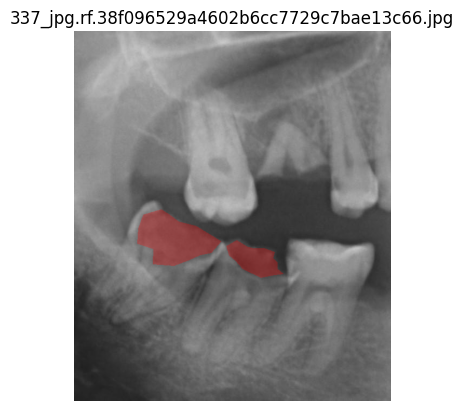

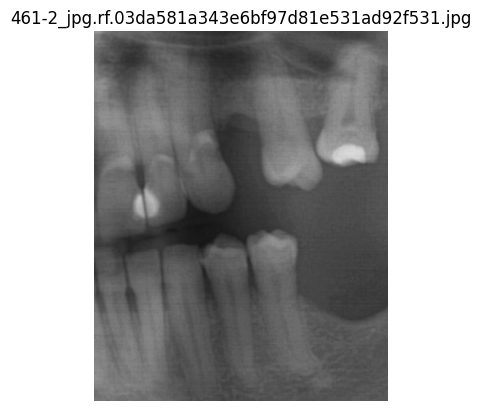

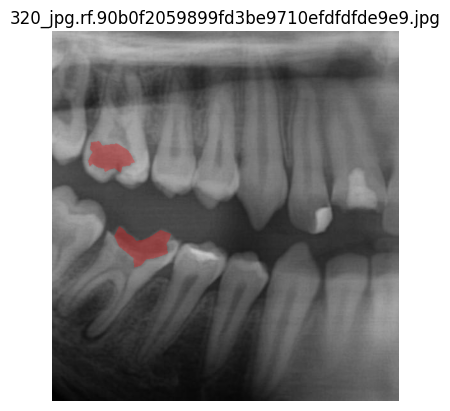

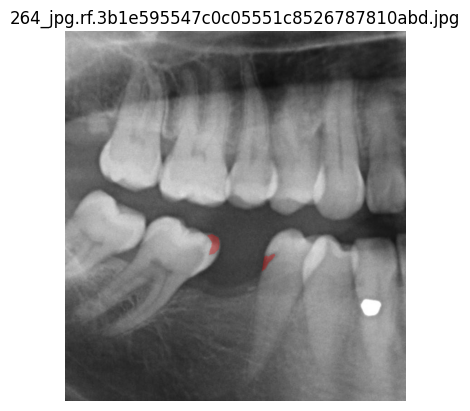

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import numpy as np

yaml_path = "/content/data_fixed.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]

img_dir = Path(data["train"])
label_dir = Path(str(img_dir).replace("/images", "/labels"))

images = list(img_dir.glob("*.jpg"))

sample = random.sample(images, min(5, len(images)))

for img_path in sample:
    label_path = label_dir / f"{img_path.stem}.txt"

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            cls = int(float(parts[0]))
            coords = list(map(float, parts[1:]))

            pts = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i+1] * h)
                pts.append([x, y])

            pts = np.array(pts, dtype=np.int32)

            cv2.fillPoly(overlay, [pts], (255, 0, 0))

    out = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    plt.imshow(out)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

## Model Training
The Ultralytics library is installed and two training runs are conducted.
The baseline run uses the YOLO26n-seg nano variant and trains for 50 epochs
at an image size of 640 pixels to establish a comparable baseline.

The improved run again uses the YOLO26n-seg and trains for up
to 100 epochs at a larger image size of 768 pixels, with early stopping applied
to prevent overfitting.

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")

model.train(
    data="/content/data_fixed.yaml",
    epochs=50,
    imgsz=640,
    batch=4,
    project="/content/drive/MyDrive/YOLO26",
    name="yolo26n_seg"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov26n_seg-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [ ]:
best_model_path_base = "/content/drive/MyDrive/YOLO26/yolov26n_seg/weights/best.pt"

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")
model.train(
    data="/content/data_fixed.yaml",
    epochs=100,
    imgsz=768,
    batch=4,
    patience=20,
    project="/content/drive/MyDrive/YOLO26",
    name="yolov26n_seg_improved"

)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov26n_seg_improved-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fab9c4669f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
best_model_path_base = "/content/drive/MyDrive/YOLO26/yolov26n_seg_improved/weights/best.pt"

## Results Visualisation
The following cells display the training results and confusion matrix for both
the baseline and improved runs.

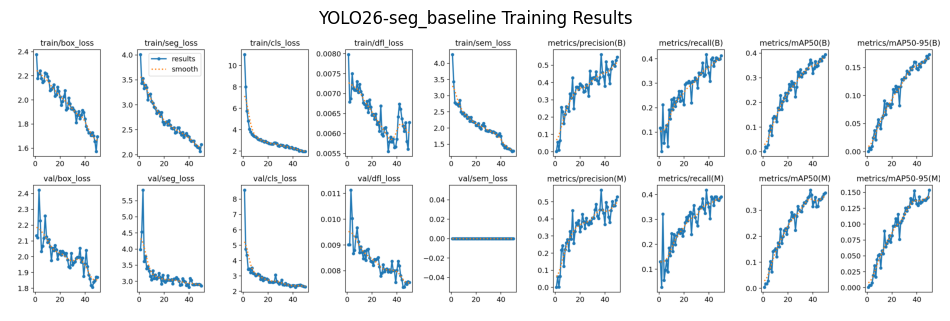

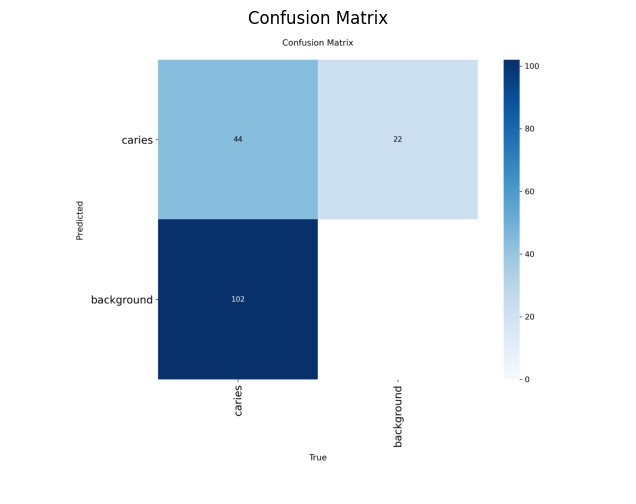

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_path = "/content/drive/MyDrive/YOLO26/yolov26n_seg-2/"

img = mpimg.imread(results_path + "results.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO26-seg_baseline Training Results")
plt.show()

cm = mpimg.imread(results_path + "confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

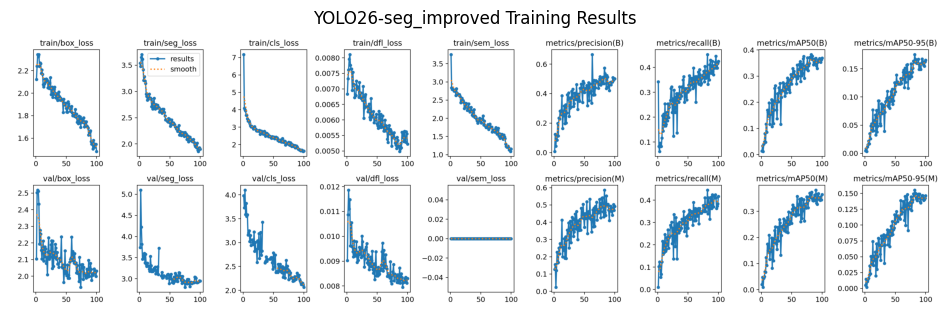

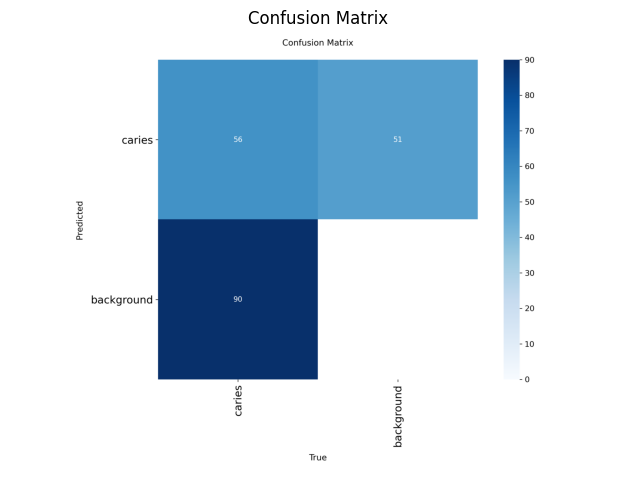

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_path = "/content/drive/MyDrive/YOLO26/yolov26n_seg_improved/"

img = mpimg.imread(results_path + "results.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO26-seg_improved Training Results")
plt.show()

cm = mpimg.imread(results_path + "confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

## Conclusion
The improved run performed comparably to the baseline across most metrics, with
the best validation mAP50 of 0.374 achieved during training

Overall performance figures from both runs are modest, which is consistent with
the findings from Experiment Two and is expected given the limited size of the
dataset. As with YOLOv8-seg, Phase One was never intended to produce
publication-ready results; the goal was to validate the segmentation pipeline
and establish configuration decisions before applying it to the CariXray dataset
in Phase Two.

These results confirm that the YOLOv26-seg pipeline is functioning correctly and
provide a direct basis for comparison with the YOLOv8-seg results from
Experiment Two.